In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pydataset import data

df = data('Housing')
df = data('austres')
df.head()


,time,austres
1,1971.25,13067.3
2,1971.50,13130.5
3,1971.75,13198.4
4,1972.00,13254.2
5,1972.25,13303.7


In [29]:
df['pct_change'] = df['austres'].pct_change()
# df.dropna(inplace=True)
# df.reset_index(drop=True, inplace=True)
df.head()

,time,austres,pct_change
0,1971.75,13198.4,NaN
1,1972.00,13254.2,0.004228
2,1972.25,13303.7,0.003735
3,1972.50,13353.9,0.003773
4,1972.75,13409.3,0.004149


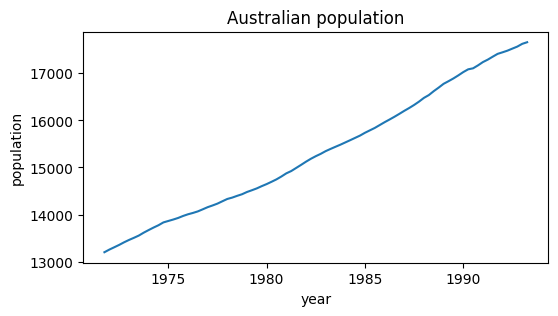

In [59]:
fig, ax1 = plt.subplots()
# plt.show()
fig.set_size_inches(6,3)
ax1.plot(df['time'], df['austres'], label='population')
ax1.set_title("Australian population")
ax1.set_xlabel('year')
ax1.set_ylabel('population')
plt.show()

## Multiple sub axes

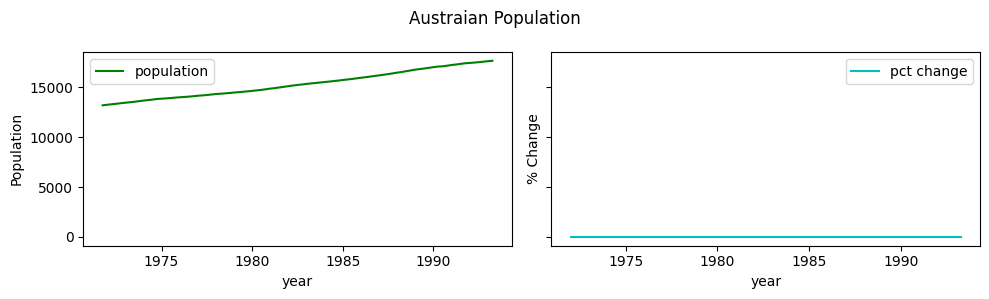

In [ ]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10,3))

# plot 1
ax1.plot(df['time'], df['austres'], '-g', label='population')
ax1.set_xlabel('year')
ax1.set_ylabel('Population')
ax1.legend()

#plot 2
ax2.plot(df['time'], df['pct_change'], '-c', label='pct change')
ax2.set_xlabel('year')
ax2.set_ylabel("% Change")
ax2.legend()

fig.suptitle("Austraian Population")
plt.tight_layout()
plt.show()

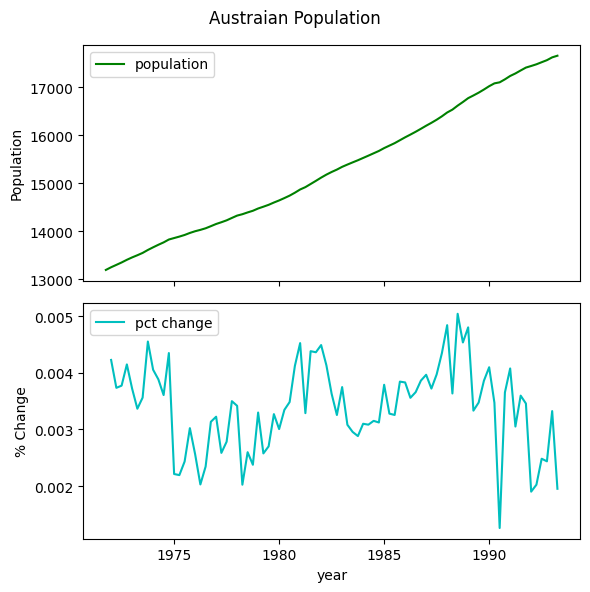

In [89]:
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(6,6), sharex=True)

# plot 1
ax1.plot(df['time'], df['austres'], '-g', label='population')
# ax1.set_xlabel('year')
ax1.set_ylabel('Population')
ax1.legend()

#plot 2
ax2.plot(df['time'], df['pct_change'], '-c', label='pct change')
ax2.set_xlabel('year')
ax2.set_ylabel("% Change")
ax2.legend()

fig.suptitle("Austraian Population")
plt.tight_layout()
plt.show()

## Annotation

In [100]:
df.head()

,time,austres,pct_change
0,1971.75,13198.4,NaN
1,1972.00,13254.2,0.004228
2,1972.25,13303.7,0.003735
3,1972.50,13353.9,0.003773
4,1972.75,13409.3,0.004149


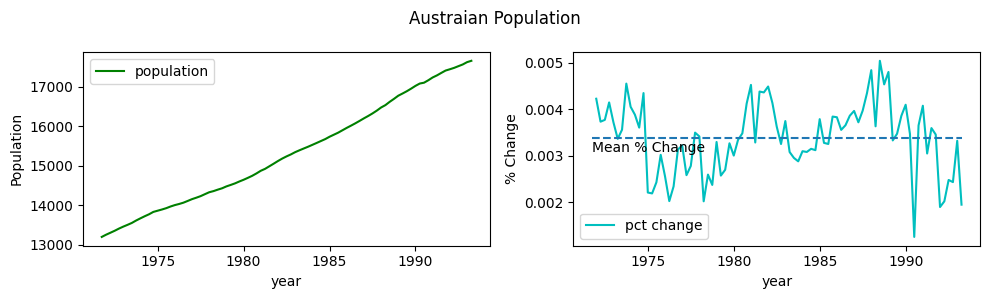

In [136]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10,3))

# plot 1
ax1.plot(df['time'], df['austres'], '-g', label='population')
ax1.set_xlabel('year')
ax1.set_ylabel('Population')
ax1.legend()

#plot 2
ax2.plot(df['time'], df['pct_change'], '-c', label='pct change')
ax2.set_xlabel('year')
ax2.set_ylabel("% Change")
ax2.hlines(y=df['pct_change'].mean(), xmin=df['time'].min(), xmax=df['time'].max(), linestyles='--')
ax2.annotate("Mean % Change", xy=(df['time'].min(), df['pct_change'].mean()-0.0003))
ax2.legend()

fig.suptitle("Austraian Population")
plt.tight_layout()
plt.show()

## Arrow

In [143]:
min_pct_change_y = df['pct_change'].min()
min_pct_change_x = df[df['pct_change'] == min_pct_change_y]['time'].iloc[0]

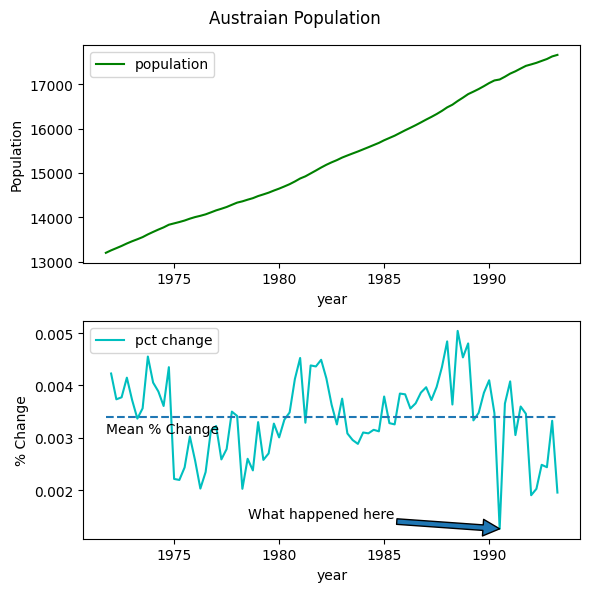

In [156]:
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(6,6))

# plot 1
ax1.plot(df['time'], df['austres'], '-g', label='population')
ax1.set_xlabel('year')
ax1.set_ylabel('Population')
ax1.legend()

#plot 2
ax2.plot(df['time'], df['pct_change'], '-c', label='pct change')
ax2.set_xlabel('year')
ax2.set_ylabel("% Change")
ax2.hlines(y=df['pct_change'].mean(), xmin=df['time'].min(), xmax=df['time'].max(), linestyles='--')
ax2.annotate("Mean % Change", xy=(df['time'].min(), df['pct_change'].mean()-0.0003))
ax2.annotate(
    "What happened here",
    xy=(min_pct_change_x, min_pct_change_y),
    xytext=(min_pct_change_x - 12, min_pct_change_y + 0.0002),
    arrowprops={}
)
ax2.legend()

fig.suptitle("Austraian Population")
plt.tight_layout()
plt.show()

## Bar Plots and Pie Plots

In [158]:
df = data('Housing')
df.head()

,price,lotsize,bedrooms,bathrms,stories,driveway,recroom,fullbase,gashw,airco,garagepl,prefarea
1,42000.0,5850,3,1,2,yes,no,yes,no,no,1,no
2,38500.0,4000,2,1,1,yes,no,no,no,no,0,no
3,49500.0,3060,3,1,1,yes,no,no,no,no,0,no
4,60500.0,6650,3,1,2,yes,yes,no,no,no,0,no
5,61000.0,6360,2,1,1,yes,no,no,no,no,0,no


In [164]:
story_counts = df['stories'].value_counts()
story_counts

stories
2    238
1    227
4     41
3     40
Name: count, dtype: int64

Text(0.5, 0.98, 'Houses with Number of Stories')

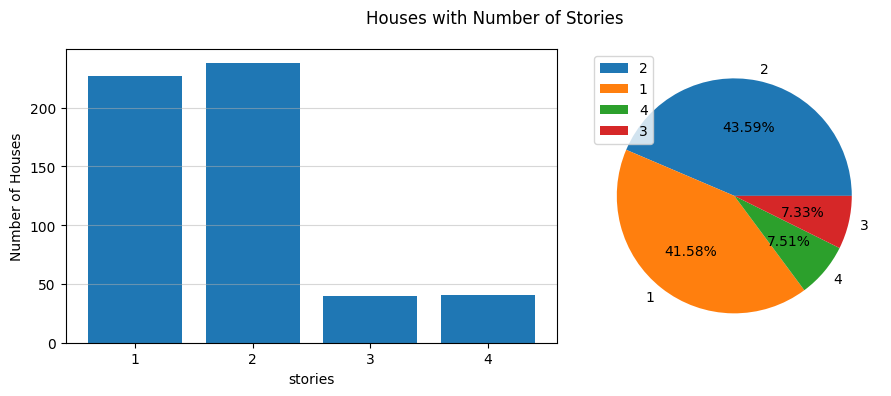

In [197]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10,4))
ax1.bar(
    x=story_counts.index,
    height=story_counts,
    label='stories')
ax1.set_xlabel('stories')
ax1.set_ylabel('Number of Houses')
ax1.set_xticks(story_counts.index)
ax1.grid(axis='y', alpha=0.5)
ax2.pie(story_counts, labels=story_counts.index, autopct='%.2f%%')
ax2.legend()

fig.set_tight_layout(tight=True)
fig.suptitle('Houses with Number of Stories')


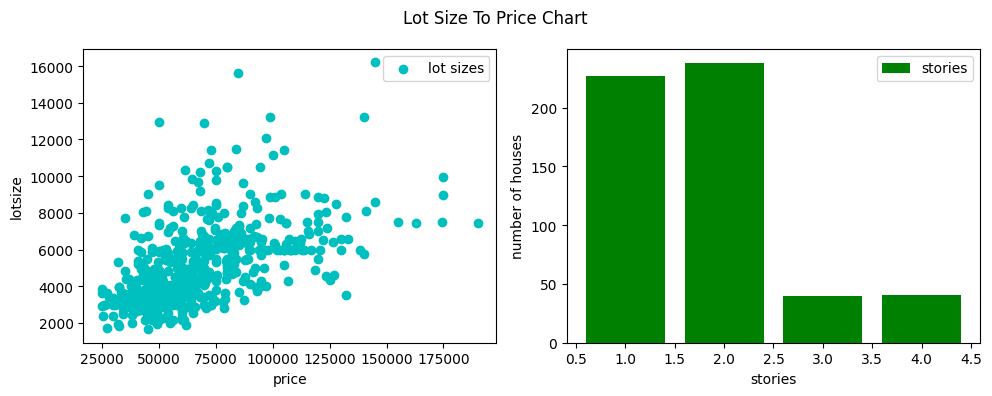

In [206]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,4))
ax[0].scatter(
    x=df['price'],
    y=df['lotsize'],
    label='lot sizes',
    color='c'
)
ax[0].set_xlabel('price')
ax[0].set_ylabel('lotsize')
ax[0].legend()

ax[1].bar(
    x=df['stories'].value_counts().index,
    height=df['stories'].value_counts(),
    label='stories',
    color='g'
)
ax[1].set_xlabel('stories')
ax[1].set_ylabel('number of houses')
ax[1].legend()
fig.suptitle('Lot Size To Price Chart')
fig.tight_layout()

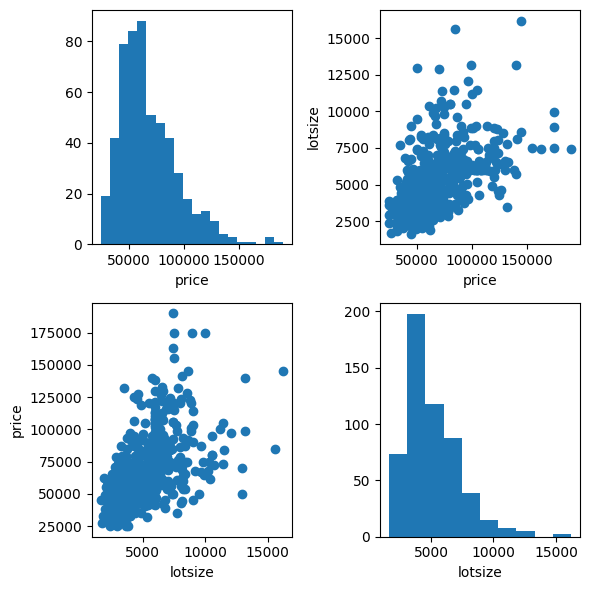

In [218]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(6,6))

ax[0, 0].hist(df['price'], bins=20)
ax[0,0].set_xlabel('price')

ax[0, 1].scatter(df['price'], df['lotsize'])
ax[0,1].set_xlabel('price')
ax[0,1].set_ylabel('lotsize')

ax[1, 0].scatter(df['lotsize'], df['price'])
ax[1,0].set_xlabel('lotsize')
ax[1,0].set_ylabel('price')

ax[1, 1].hist(df['lotsize'], bins=10)
ax[1,1].set_xlabel('lotsize')

fig.tight_layout()